### Import Modules


In [1]:
# Standard Library
import random
from datetime import datetime, timezone
from pathlib import Path

# Packages
import numpy
import pandas
from matplotlib import pyplot

### Constants & Config


In [2]:
# Paths
ROOT_DIR = Path("../").resolve()

# Reproducibility
RANDOM_STATE = 42
RNG = numpy.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)
numpy.random.seed(RANDOM_STATE)

# Data
TEST_SIZE = 0.2
START_DATE = datetime(2013, 9, 1, tzinfo=timezone.utc)
SEED_PATH = (
    ROOT_DIR
    / "database"
    / "seed"
    / "transaction_inferences"
    / "creditcard_transactions.csv.gz"
)

### Load Data


In [3]:
seed_df = pandas.read_csv(
    SEED_PATH,
    compression="gzip",
    dtype={
        "Time": "float64",
        **{f"V{i}": "float64" for i in range(1, 29)},
        "Amount": "float64",
        "Class": "int8",
    },
)

df = pandas.DataFrame({
    "is_fraud": seed_df["Class"].astype("int64"),
    "transaction_timestamp": (
        START_DATE.timestamp() + seed_df["Time"]
    ).astype("int64"),
    "amount": seed_df["Amount"],
    **{f"v{i}": seed_df[f"V{i}"] for i in range(1, 29)},
})

print(f"Loaded {len(df):,} rows")
df.head()

Loaded 284,807 rows


,is_fraud,transaction_timestamp,amount,v1,v2,v3,v4,v5,v6,v7,...,v19,v20,v21,v22,v23,v24,v25,v26,v27,v28
0,0,1377993600,149.62,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,0,1377993600,2.69,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,0,1377993601,378.66,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,0,1377993601,123.50,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,0,1377993602,69.99,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153


### Exploratory Data Analysis


Shape: (284807, 31)
Null Total: 0


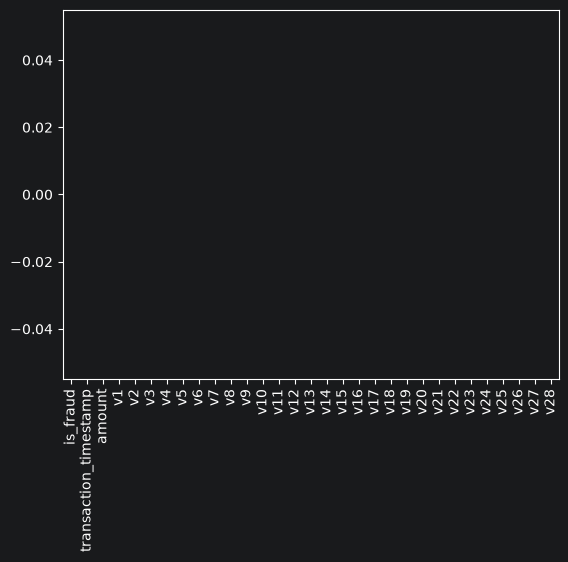

In [4]:
# Basic Overview
print(f"Shape: {df.shape}")
print(f"Null Total: {df.isnull().sum().sum()}")
df.isnull().sum().plot(kind="bar")
pyplot.show()

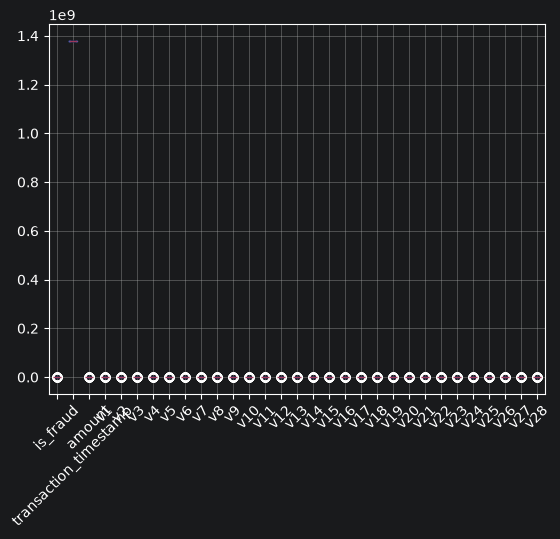

In [5]:
# Feature Distribution
df.boxplot()
pyplot.xticks(rotation=45)
pyplot.show()

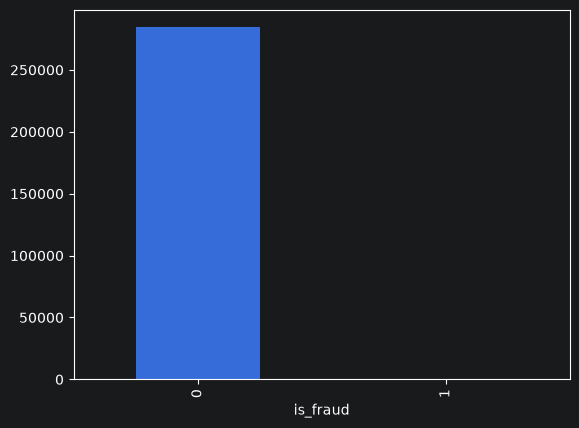

is_fraud
0    284315
1       492
Name: count, dtype: int64

In [6]:
# Class Distribution
df["is_fraud"].value_counts().plot(kind="bar")
pyplot.show()
df["is_fraud"].value_counts()